In [313]:
import os
import glob
import random
from collections import Counter, defaultdict
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [314]:
# ====== НАСТРОЙКА ======
current_dir = os.getcwd()
project_dir = os.path.dirname(current_dir)

# Путь к dataset
DATASETS_ROOT = os.path.join(project_dir, "dataset")
DATASET_INDEX = 14  # <-- выбираешь нужный датасет


# ====== НАХОДИМ ДАТАСЕТЫ ======
dataset_dirs = [os.path.join(DATASETS_ROOT, d) for d in os.listdir(DATASETS_ROOT)]
dataset_dirs = [d for d in dataset_dirs if os.path.isdir(d)]

dataset_dirs.sort()
print(DATASETS_ROOT)
selected_dataset = dataset_dirs[DATASET_INDEX]
print(f"Selected dataset: {selected_dataset}")


# ====== НАХОДИМ ФАЙЛЫ ======
image_paths = glob.glob(os.path.join(selected_dataset, "**", "*.jpg"), recursive=True)
image_paths += glob.glob(os.path.join(selected_dataset, "**", "*.png"), recursive=True)
image_paths += glob.glob(os.path.join(selected_dataset, "**", "*.jpeg"), recursive=True)

EXCLUDED_LABEL_FILES = ["README.dataset.txt", "README.roboflow.txt"]
# Находим все txt файлы и фильтруем
all_txt_paths = glob.glob(os.path.join(selected_dataset, "**", "*.txt"), recursive=True)

# Функция для проверки, нужно ли исключить файл
def is_excluded(filepath, excluded_patterns):
    filename = os.path.basename(filepath)
    return filename in excluded_patterns

label_paths = [p for p in all_txt_paths if not is_excluded(p, EXCLUDED_LABEL_FILES)]

print(f"\nTotal images: {len(image_paths)}")
print(f"Total labels: {len(label_paths)}")

g:\study\University\6_course\вкр_мага\project\dataset
Selected dataset: g:\study\University\6_course\вкр_мага\project\dataset\pendeteksi-id-card-event

Total images: 71
Total labels: 71


In [315]:
# ====== 1. ФОРМАТЫ ======
formats = [os.path.splitext(p)[1] for p in image_paths]
format_counter = Counter(formats)

print("\nImage formats:")
for fmt, count in format_counter.items():
    print(f"{fmt}: {count}")


Image formats:
.jpg: 71


In [316]:
# # ====== 2. РАЗМЕРЫ ИЗОБРАЖЕНИЙ ======
# widths = []
# heights = []

# def read_image(path):
#     """Читает изображение даже с русскими символами в пути"""
#     with open(path, 'rb') as f:
#         data = np.frombuffer(f.read(), dtype=np.uint8)
#         img = cv2.imdecode(data, cv2.IMREAD_COLOR)
#     return img

# # Использование:
# for img_path in image_paths:
#     img = read_image(img_path)
#     if img is None:
#         continue
#     h, w = img.shape[:2]
#     widths.append(w)
#     heights.append(h)
    
# plt.figure()
# plt.scatter(widths, heights, alpha=0.3)
# plt.title("Image sizes (width vs height)")
# plt.xlabel("Width")
# plt.ylabel("Height")
# plt.show()

In [317]:
# ====== 3. КЛАССЫ ======
class_counter = Counter()

for label_path in label_paths:
    with open(label_path, "r") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) == 0:
                continue
            class_id = parts[0]
            class_counter[class_id] += 1

print("\nClasses distribution:")
for cls, count in class_counter.items():
    print(f"class {cls}: {count}")


Classes distribution:
class 2: 63
class 0: 7
class 1: 7


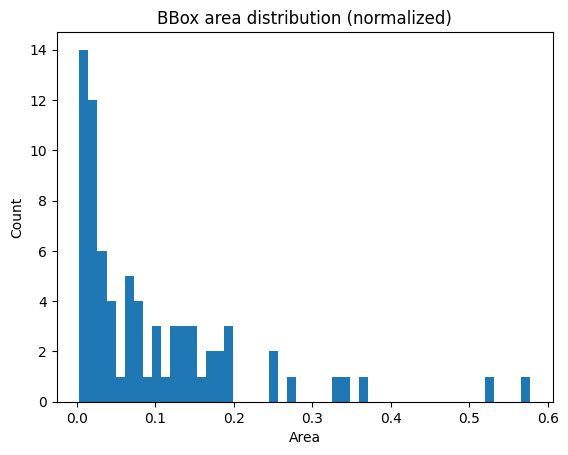

In [318]:
# ====== 4. BBOX ПЛОЩАДИ ======
bbox_areas = []

for label_path in label_paths:
    with open(label_path, "r") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) != 5:
                continue

            _, x, y, w, h = map(float, parts)

            area = w * h  # в нормализованных координатах
            bbox_areas.append(area)

plt.figure()
plt.hist(bbox_areas, bins=50)
plt.title("BBox area distribution (normalized)")
plt.xlabel("Area")
plt.ylabel("Count")
plt.show()

In [319]:
# ====== 5. ИЗОБРАЖЕНИЯ БЕЗ LABEL ======
label_files_set = set([os.path.splitext(os.path.basename(p))[0] for p in label_paths])

images_without_labels = []

for img_path in image_paths:
    name = os.path.splitext(os.path.basename(img_path))[0]
    if name not in label_files_set:
        images_without_labels.append(img_path)

print(f"\nImages without labels: {len(images_without_labels)}")


Images without labels: 0


Image: g:\study\University\6_course\вкр_мага\project\dataset\pendeteksi-id-card-event\train\images\images-4-_jpeg.rf.d3357b80b5d967ecc62210c75eca344f.jpg
Label: g:\study\University\6_course\вкр_мага\project\dataset\pendeteksi-id-card-event\train\labels\labels-4-_jpeg.rf.d3357b80b5d967ecc62210c75eca344f.txt
Label exists: False
--------------------------------------------------


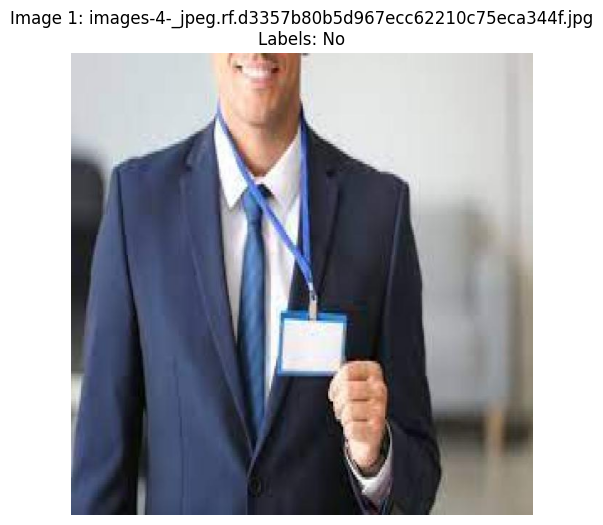

Image: g:\study\University\6_course\вкр_мага\project\dataset\pendeteksi-id-card-event\test\images\IMG_20240603_103853_jpg.rf.40d417e636ec05add4a18e516b63000b.jpg
Label: g:\study\University\6_course\вкр_мага\project\dataset\pendeteksi-id-card-event\test\labels\IMG_20240603_103853_jpg.rf.40d417e636ec05add4a18e516b63000b.txt
Label exists: True
--------------------------------------------------


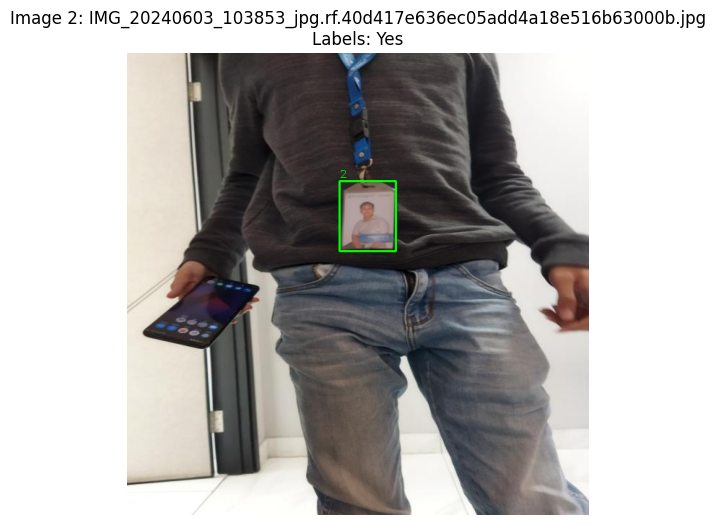

Image: g:\study\University\6_course\вкр_мага\project\dataset\pendeteksi-id-card-event\train\images\0916_id_card_jpg.rf.dce9527127dc4c037337f3823160fe62.jpg
Label: g:\study\University\6_course\вкр_мага\project\dataset\pendeteksi-id-card-event\train\labels\0916_id_card_jpg.rf.dce9527127dc4c037337f3823160fe62.txt
Label exists: True
--------------------------------------------------


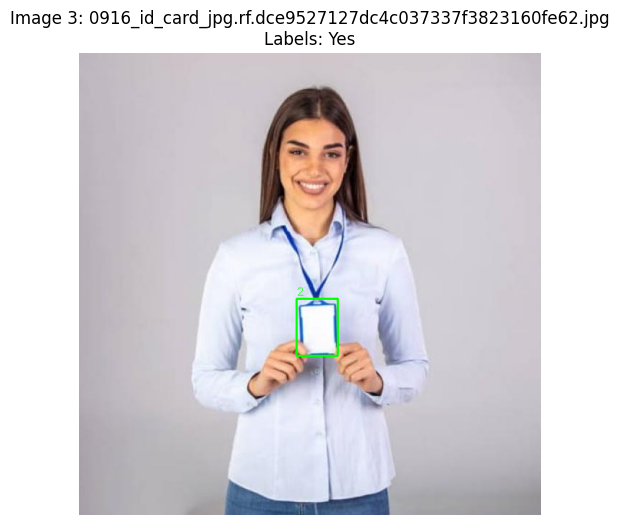

Image: g:\study\University\6_course\вкр_мага\project\dataset\pendeteksi-id-card-event\valid\images\IMG_20240605_003930_jpg.rf.137afb4d85cff16f975ce3e3c808891b.jpg
Label: g:\study\University\6_course\вкр_мага\project\dataset\pendeteksi-id-card-event\valid\labels\IMG_20240605_003930_jpg.rf.137afb4d85cff16f975ce3e3c808891b.txt
Label exists: True
--------------------------------------------------


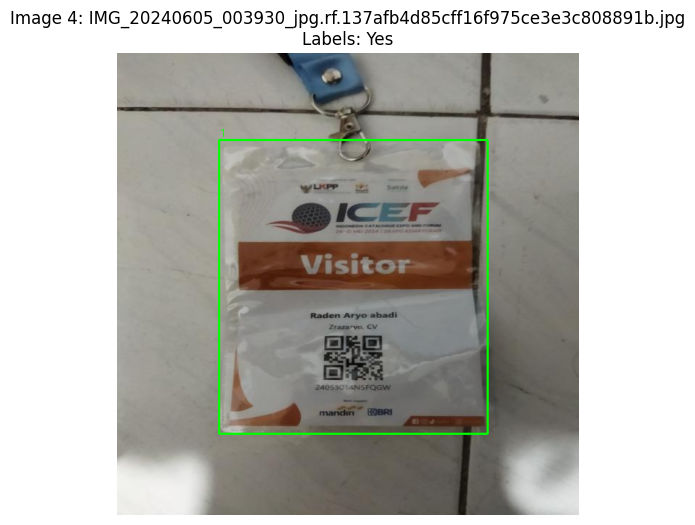

Image: g:\study\University\6_course\вкр_мага\project\dataset\pendeteksi-id-card-event\test\images\IMG_20240603_103854_jpg.rf.1944d8c4ba2367932439b1a259c399db.jpg
Label: g:\study\University\6_course\вкр_мага\project\dataset\pendeteksi-id-card-event\test\labels\IMG_20240603_103854_jpg.rf.1944d8c4ba2367932439b1a259c399db.txt
Label exists: True
--------------------------------------------------


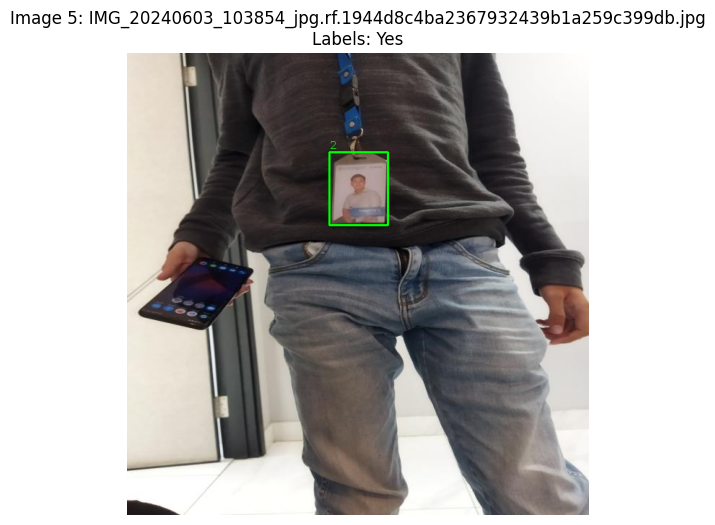

In [320]:
# ====== 6. ВИЗУАЛИЗАЦИЯ (5 СЛУЧАЙНЫХ) ======
def draw_bboxes(image, label_path):
    h, w = image.shape[:2]

    if not os.path.exists(label_path):
        return image

    with open(label_path, "r") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) != 5:
                continue

            cls, x, y, bw, bh = map(float, parts)

            x1 = int((x - bw / 2) * w)
            y1 = int((y - bh / 2) * h)
            x2 = int((x + bw / 2) * w)
            y2 = int((y + bh / 2) * h)

            cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 2)
            cv2.putText(image, str(int(cls)), (x1, y1 - 5),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)

    return image

def read_image(path):
    """Читает изображение даже с русскими символами в пути"""
    with open(path, 'rb') as f:
        data = np.frombuffer(f.read(), dtype=np.uint8)
        img = cv2.imdecode(data, cv2.IMREAD_COLOR)
    return img

def get_label_path(img_path):
    """Преобразует путь к изображению в путь к лейблу"""
    # Заменяем 'images' на 'labels' в пути
    label_path = img_path.replace('images', 'labels')
    # Меняем расширение на .txt
    label_path = os.path.splitext(label_path)[0] + ".txt"
    return label_path

sample_images = random.sample(image_paths, min(5, len(image_paths)))

for i, img_path in enumerate(sample_images):
    img = read_image(img_path)
    
    # Используем правильную функцию для получения пути к лейблу
    label_path = get_label_path(img_path)
    print(f"Image: {img_path}")
    print(f"Label: {label_path}")
    print(f"Label exists: {os.path.exists(label_path)}")
    print("-" * 50)
    
    img = draw_bboxes(img, label_path)
    
    # Создаём отдельную фигуру для каждого изображения
    plt.figure(figsize=(8, 6))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(f"Image {i+1}: {os.path.basename(img_path)}\nLabels: {'Yes' if os.path.exists(label_path) else 'No'}")
    plt.axis("off")
    plt.show()